### `Time Series Forcasting on Google Stock Prices`

#### `Using Google's 'GOOG' class C stock shares price history from 2020 to 2024`

#### `Google has two main stock tickers:`

GOOG -> Class C Shares

GOOGL -> Class A Shares


The goal of this time series forecast is to analyze stock prices over the years to making machine learning predictions also performing technical analysis with indicators like RSI and MACD

In [ ]:
import yfinance as yf

# Get Google stock data
google = yf.Ticker("GOOG")

# Historical market data
data = google.history(start="2020-01-01", end="2025-01-01")

data.head()

In [ ]:
data.to_csv("../Dataset/google_stock_data.csv")
print('File Saved Successfully')

#### `Importing Libraries`

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

import warnings
warnings.filterwarnings('ignore')

In [49]:
goog = pd.read_csv('../Dataset/google_stock_data.csv')

goog.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2020-01-02 00:00:00-05:00,66.531272,67.849944,66.531272,67.811760,28132000,0.0,0.0
1,2020-01-03 00:00:00-05:00,66.844216,68.066186,66.729360,67.479004,23728000,0.0,0.0
2,2020-01-06 00:00:00-05:00,66.950335,69.256400,66.950335,69.142838,34646000,0.0,0.0
3,2020-01-07 00:00:00-05:00,69.327831,69.578270,68.952903,69.099701,30054000,0.0,0.0
4,2020-01-08 00:00:00-05:00,69.037203,70.004269,68.975711,69.644226,30560000,0.0,0.0


#### `Removing timestamp from date`

In [50]:
goog['Date'] = pd.to_datetime(goog['Date'], utc=True)
goog['Date'] = goog['Date'].dt.date

goog = goog.set_index('Date')

goog.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-02,66.531272,67.849944,66.531272,67.811760,28132000,0.0,0.0
2020-01-03,66.844216,68.066186,66.729360,67.479004,23728000,0.0,0.0
2020-01-06,66.950335,69.256400,66.950335,69.142838,34646000,0.0,0.0
2020-01-07,69.327831,69.578270,68.952903,69.099701,30054000,0.0,0.0
2020-01-08,69.037203,70.004269,68.975711,69.644226,30560000,0.0,0.0


#### `Summary Statistics`

In [51]:
goog.info()
goog.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1258 non-null   float64
 1   High          1258 non-null   float64
 2   Low           1258 non-null   float64
 3   Close         1258 non-null   float64
 4   Volume        1258 non-null   int64  
 5   Dividends     1258 non-null   float64
 6   Stock Splits  1258 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.6+ KB


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000
mean,118.879406,120.258703,117.644724,118.967149,2.741160e+07,0.000477,0.015898
std,32.714784,32.910475,32.486836,32.679903,1.271913e+07,0.009759,0.563884
min,52.395337,53.129810,50.264135,52.400795,6.809800e+06,0.000000,0.000000
25%,93.405524,94.622526,91.898028,93.422997,1.885022e+07,0.000000,0.000000
50%,120.063292,121.314008,119.117056,120.031559,2.445790e+07,0.000000,0.000000
75%,140.563853,141.840788,139.349200,140.539917,3.213400e+07,0.000000,0.000000
max,197.620878,201.950964,195.789307,197.252594,9.779860e+07,0.200000,20.000000


#### `Handling Missing Values`

In [52]:
goog.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

#### `Data Visualization`

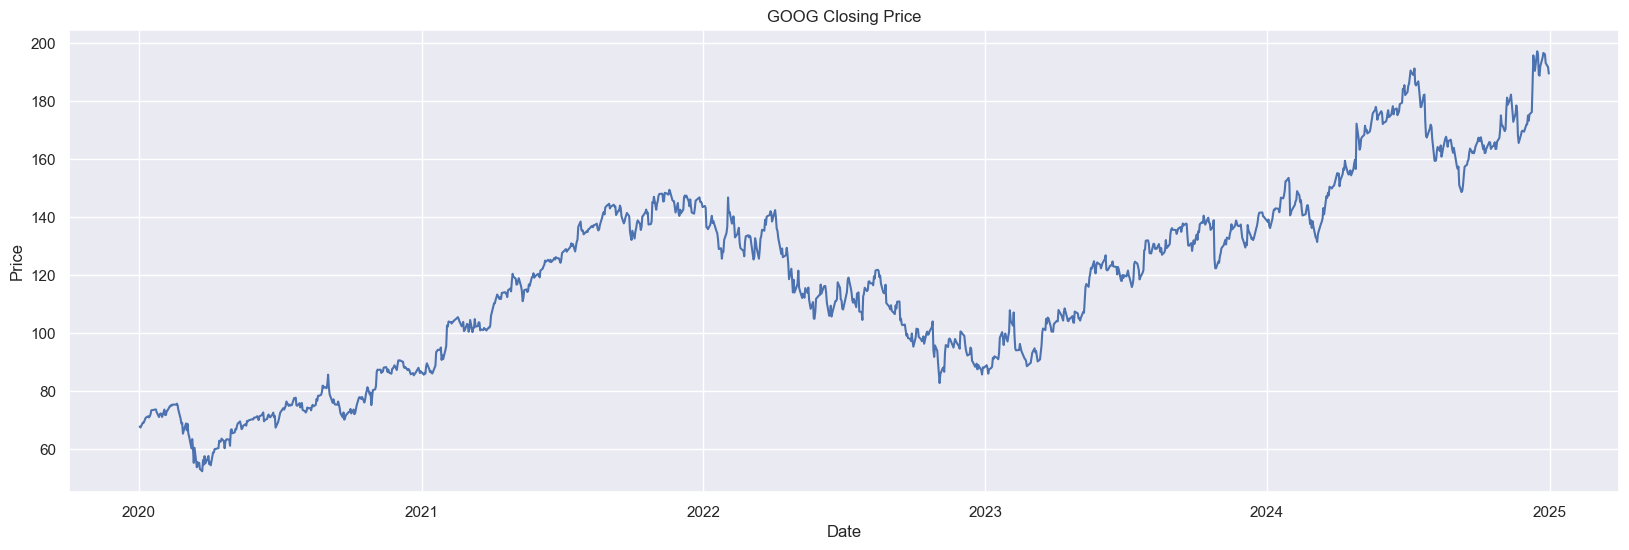

In [53]:
plt.figure(figsize=(20, 6))
plt.plot(goog.index, goog['Close'])
plt.title('GOOG Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()           

#### `Baseline Forecast`

Helps to compare advanced models

##### `Moving Average Forcast`

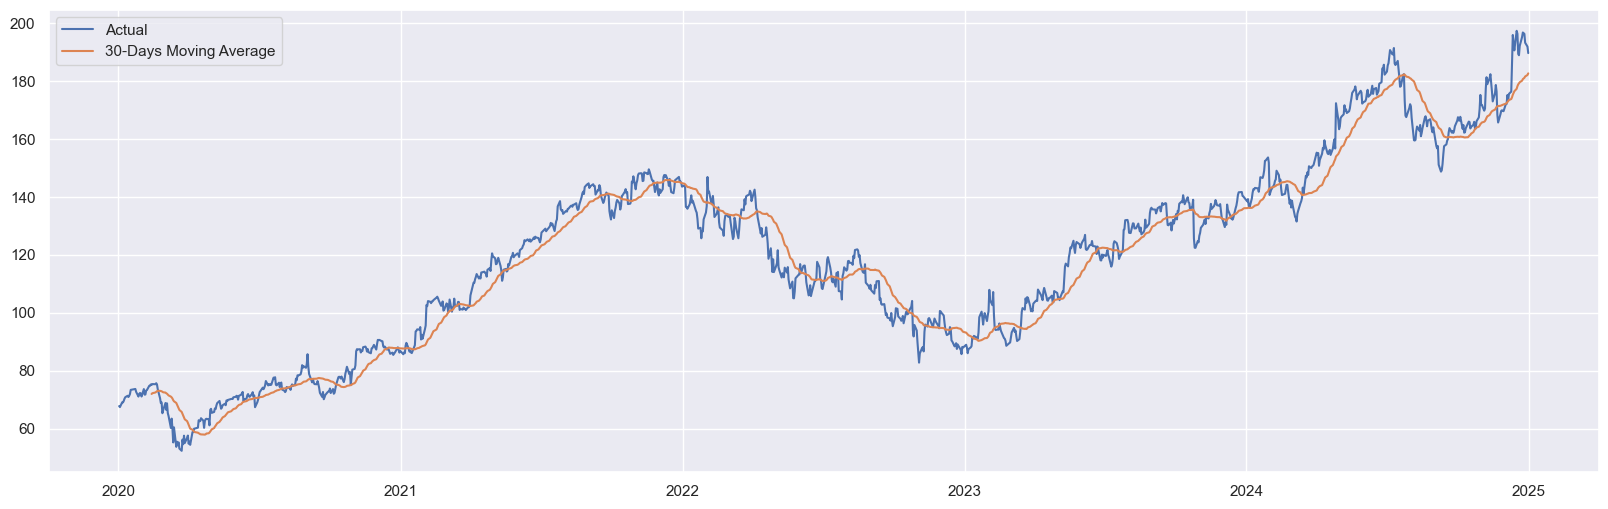

In [54]:
goog['MA_30'] = goog['Close'].rolling(window=30).mean()

plt.figure(figsize=(20, 6))
plt.plot(goog['Close'], label='Actual')
plt.plot(goog['MA_30'], label='30-Days Moving Average')
plt.legend()
plt.show()

#### `Data Splitting, Prediction and Evaluation`

In [55]:
train = goog[pd.to_datetime(goog.index).year == 2023]
test = goog[pd.to_datetime(goog.index).year == 2024]

In [56]:
train.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_30
Date,,,,,,,,
2023-01-03,89.098520,90.804516,88.295111,88.969574,20738500,0.0,0.0,93.156196
2023-01-04,90.268907,90.497030,87.085047,87.987633,27046500,0.0,0.0,92.855663
2023-01-05,87.352832,87.491692,85.855126,86.063416,23136100,0.0,0.0,92.556122
2023-01-06,86.648620,87.749581,84.873195,87.442108,26612600,0.0,0.0,92.252944
2023-01-09,88.468661,90.090349,87.858672,88.076881,22996700,0.0,0.0,91.921663


In [57]:
test.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,MA_30
Date,,,,,,,,
2024-01-02,138.463221,139.469955,136.618367,138.423538,20071900,0.0,0.0,136.096656
2024-01-03,137.471378,139.941092,137.302749,139.217041,18974300,0.0,0.0,136.209728
2024-01-04,138.711198,139.489794,136.886170,136.915924,18253300,0.0,0.0,136.213696
2024-01-05,137.225382,137.679645,135.735614,136.271210,15439500,0.0,0.0,136.173029
2024-01-08,136.876284,139.494786,136.757266,139.385681,17645300,0.0,0.0,136.189892


#### `ARIMA Forecasting`

In [58]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Close'], order=(5, 1, 0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  250
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -552.989
Date:                Fri, 15 May 2026   AIC                           1117.978
Time:                        21:58:37   BIC                           1139.083
Sample:                             0   HQIC                          1126.473
                                - 250                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0356      0.064      0.559      0.576      -0.089       0.160
ar.L2         -0.0280      0.077     -0.366      0.714      -0.178       0.122
ar.L3         -0.0228      0.064     -0.358      0.7

In [59]:
forecast = model_fit.forecast(steps=len(test))
print(forecast)

250    139.721946
251    139.713803
252    139.848738
253    139.867273
254    139.896044
          ...    
497    139.883597
498    139.883597
499    139.883597
500    139.883597
501    139.883597
Name: predicted_mean, Length: 252, dtype: float64


#### `Prediction Vs Actual Plot`

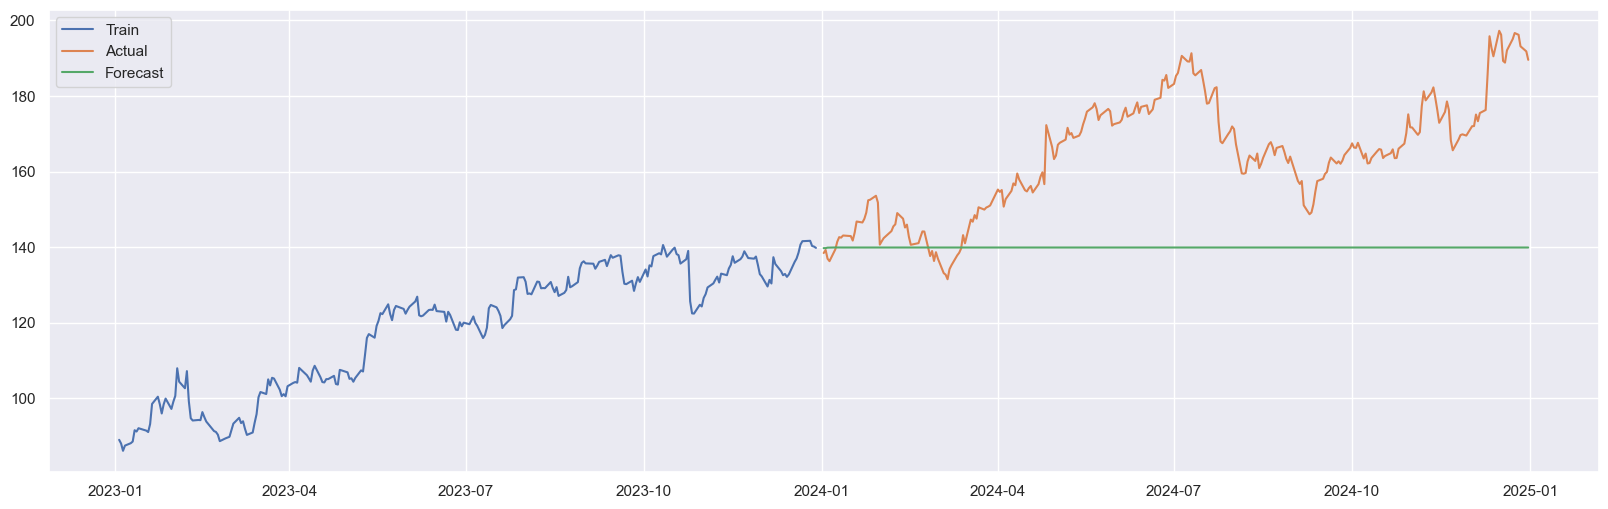

In [60]:
plt.figure(figsize=(20, 6))

plt.plot(train.index, train['Close'], label='Train')
plt.plot(test.index, test['Close'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.show()

#### `Model Evaluation`

In [61]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(test['Close'], forecast)
rmse = root_mean_squared_error(test['Close'], forecast)

print('MAE: ', mae)
print('RMSE: ', rmse)

MAE:  24.690681260333797
RMSE:  28.749046109849004
